**<center><font size=8>Customer Churn Prediction</center></font>**

<center><p float="center">
  <img src="https://dezyre.gumlet.io/images/blog/churn-models/Customer_Churn_Prediction_Models_in_Machine_Learning.png?w=940&dpr=1.3" height=400 width=750>
</p></center>





## **Problem Statement**

### **Objective**

The bank is currently faced with the challenge of accurately predicting which customers are at risk of churning based on an array of data features. The available dataset encompasses a variety of characteristics, including demographic information, product usage details, and customer engagement metrics. The primary objective is to construct a predictive model capable of utilizing these customer characteristics to classify whether a customer is at risk of churn.

By accurately identifying at-risk customers, the bank can intervene proactively with tailored offers, improved customer support, or innovative loyalty programs before a customer's decision to leave is finalized. The end goal is to elevate customer engagement, foster loyalty, and ultimately secure its competitive advantage in the dynamic banking ecosystem.

### **Data Description**

The building block of any data science project is the data. Underneed you can find one data record which will be used in further analysis. The dataset consist of 10127 samples describing the customers and it's behavior.

The columns/features can be categorized as follow:

* ***Unique Id***:
    * **CLIENTNUM** : Unique identifier for the customer holding the account.


* ***Target***:
    * **Attrition_Flag**: Internal event (customer activity) variable - Existing Customer / Attrited Customer


* ***Demographic variables***:
    * **Customer_Age**: Demographic variable - Customer's Age in Years.
    * **Gender**: Demographic variable - M=Male, F=Female.
    * **Dependent_count**: Demographic variable - Number of dependents.
    * **Education_Level**: Demographic variable - Educational Qualification of the account holder (example: high school, college graduate, etc.).
    * **Marital_Status**: Demographic variable - Married, Single, Divorced, Unknown.
    * **Income_Category**: Demographic variable - Annual Income Category of the account holder (<$40K, $40K - 60K, $60K - $80K, $80K-$120K, >$120K, Unknown).
    

* ***Product variables***:
    * **Card_Category**: Product Variable - Type of Card (Blue, Silver, Gold, Platinum).
    * **Months_on_book**: Period of relationship with bank.
    * **Total_Relationship_Count**: Total no. of products held by the customer.
    * **Months_Inactive_12_mon**: No. of Months in the last 12 months.
    * **Contacts_Count_12_mon**: No. of Contacts in the last 12 months.
    * **Credit_Limit**: Credit Limit on the Credit Card.
    * **Total_Revolving_Bal**: Total Revolving Balance on the Credit Card.
    * **Avg_Open_To_Buy**: Open to Buy Credit Line (Average of last 12 months)
    * **Total_Amt_Chng_Q4_Q1**: Change in Transaction Amount (Q4 over Q1).
    * **Total_Trans_Amt**: Total Transaction Amount (Last 12 months).
    * **Total_Trans_Ct**: Total Transaction Count (Last 12 months).
    * **Total_Ct_Chng_Q4_Q1**: Change in Transaction Count (Q4 over Q1).
    * **Avg_Utilization_Ratio**: Average Card Utilization Ratio.


## **Importing Necessary Libraries**

In [1]:
import pandas as pd

In [2]:
# Pandas: Used for data manipulation and analysis.
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

# NumPy: Used for numerical operations and array handling.
import numpy as np

# Matplotlib: Used for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt

# Seaborn: Built on top of Matplotlib, provides a high-level interface for statistical graphics.
import seaborn as sns

# Scikit-learn (sklearn): A comprehensive library for machine learning tasks, including model tuning, performance evaluation, and data preprocessing.
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# DecisionTreeClassifier: A basic decision tree classifier.
from sklearn.tree import DecisionTreeClassifier

# RandomForestClassifier: An ensemble method that combines multiple decision trees.
from sklearn.ensemble import RandomForestClassifier

# GradientBoostingClassifier: Another ensemble method that builds trees sequentially, correcting the errors of previous trees.
from sklearn.ensemble import GradientBoostingClassifier


## **Loading the Data**

- The CSV file can also be directly loaded from Google Drive.

* We load our dataset from Google Drive.
* The file named **Churn Prediction`** has been stored there.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/GenAI-Course/Cus_Churn_Prediction/Churn Prediction.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Overview**

Now that the dataset is loaded, the next step is to understand what the data looks like. Before we move on to building models, it’s important to take a closer look at the structure and contents of the dataset.

In this step, we will:

- Check how many rows and columns the dataset has  
- Look at the first few rows to get a feel for the data  
- See what data types each column has  
- Check for any missing or unusual values  

This basic overview will help us decide what kind of cleaning or preparation the data might need. Let’s explore the dataset and understand what we’re working with.

In [4]:
data.shape

(10127, 21)

The dataset consists of 10127 rows and 21 columns

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

The dataset contains 10,127 records with 21 features, including a mix of numerical and categorical variables, and no missing values.

In [6]:
data.describe()


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,739177606.33,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,36903783.45,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,708082083.00,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,713036770.50,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,717926358.00,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,773143533.00,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,828343083.00,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


**Check for Duplicate Rows**

In [7]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")


Number of duplicate rows: 0


There are no duplicate records in the dataset. If any were present, they could be removed using `data.drop_duplicates()`.

## **Exploratory Data Analysis**

Now that we understand the structure of our dataset, it’s time to take a closer look at the details through Exploratory Data Analysis (EDA). This step helps us find patterns in the data and learn more about how different features behave.

In this section, we will:

- Look at how numerical features like age, credit limit, and transaction amounts are distributed  
- Check the balance of categorical features such as gender, card type, and income category  
- Explore how these features might relate to customer churn  

Doing EDA helps us understand the data better and prepares us for building a more accurate and meaningful model.

Let’s start exploring.

We manually categorize the columns into numerical and categorical types by inspecting the data, as some columns contain numeric values but represent categories—making it difficult to accurately separate them using prompting methods.

In [8]:
cat_columns = ['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status',
               'Income_Category', 'Card_Category','Total_Relationship_Count', 'Months_Inactive_12_mon',
               'Contacts_Count_12_mon', 'Dependent_count']
num_columns = ['Customer_Age', 'Months_on_book',
               'Credit_Limit', 'Total_Revolving_Bal',
               'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
               'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


### **Univariate Analysis**

#### **Categorical Column**

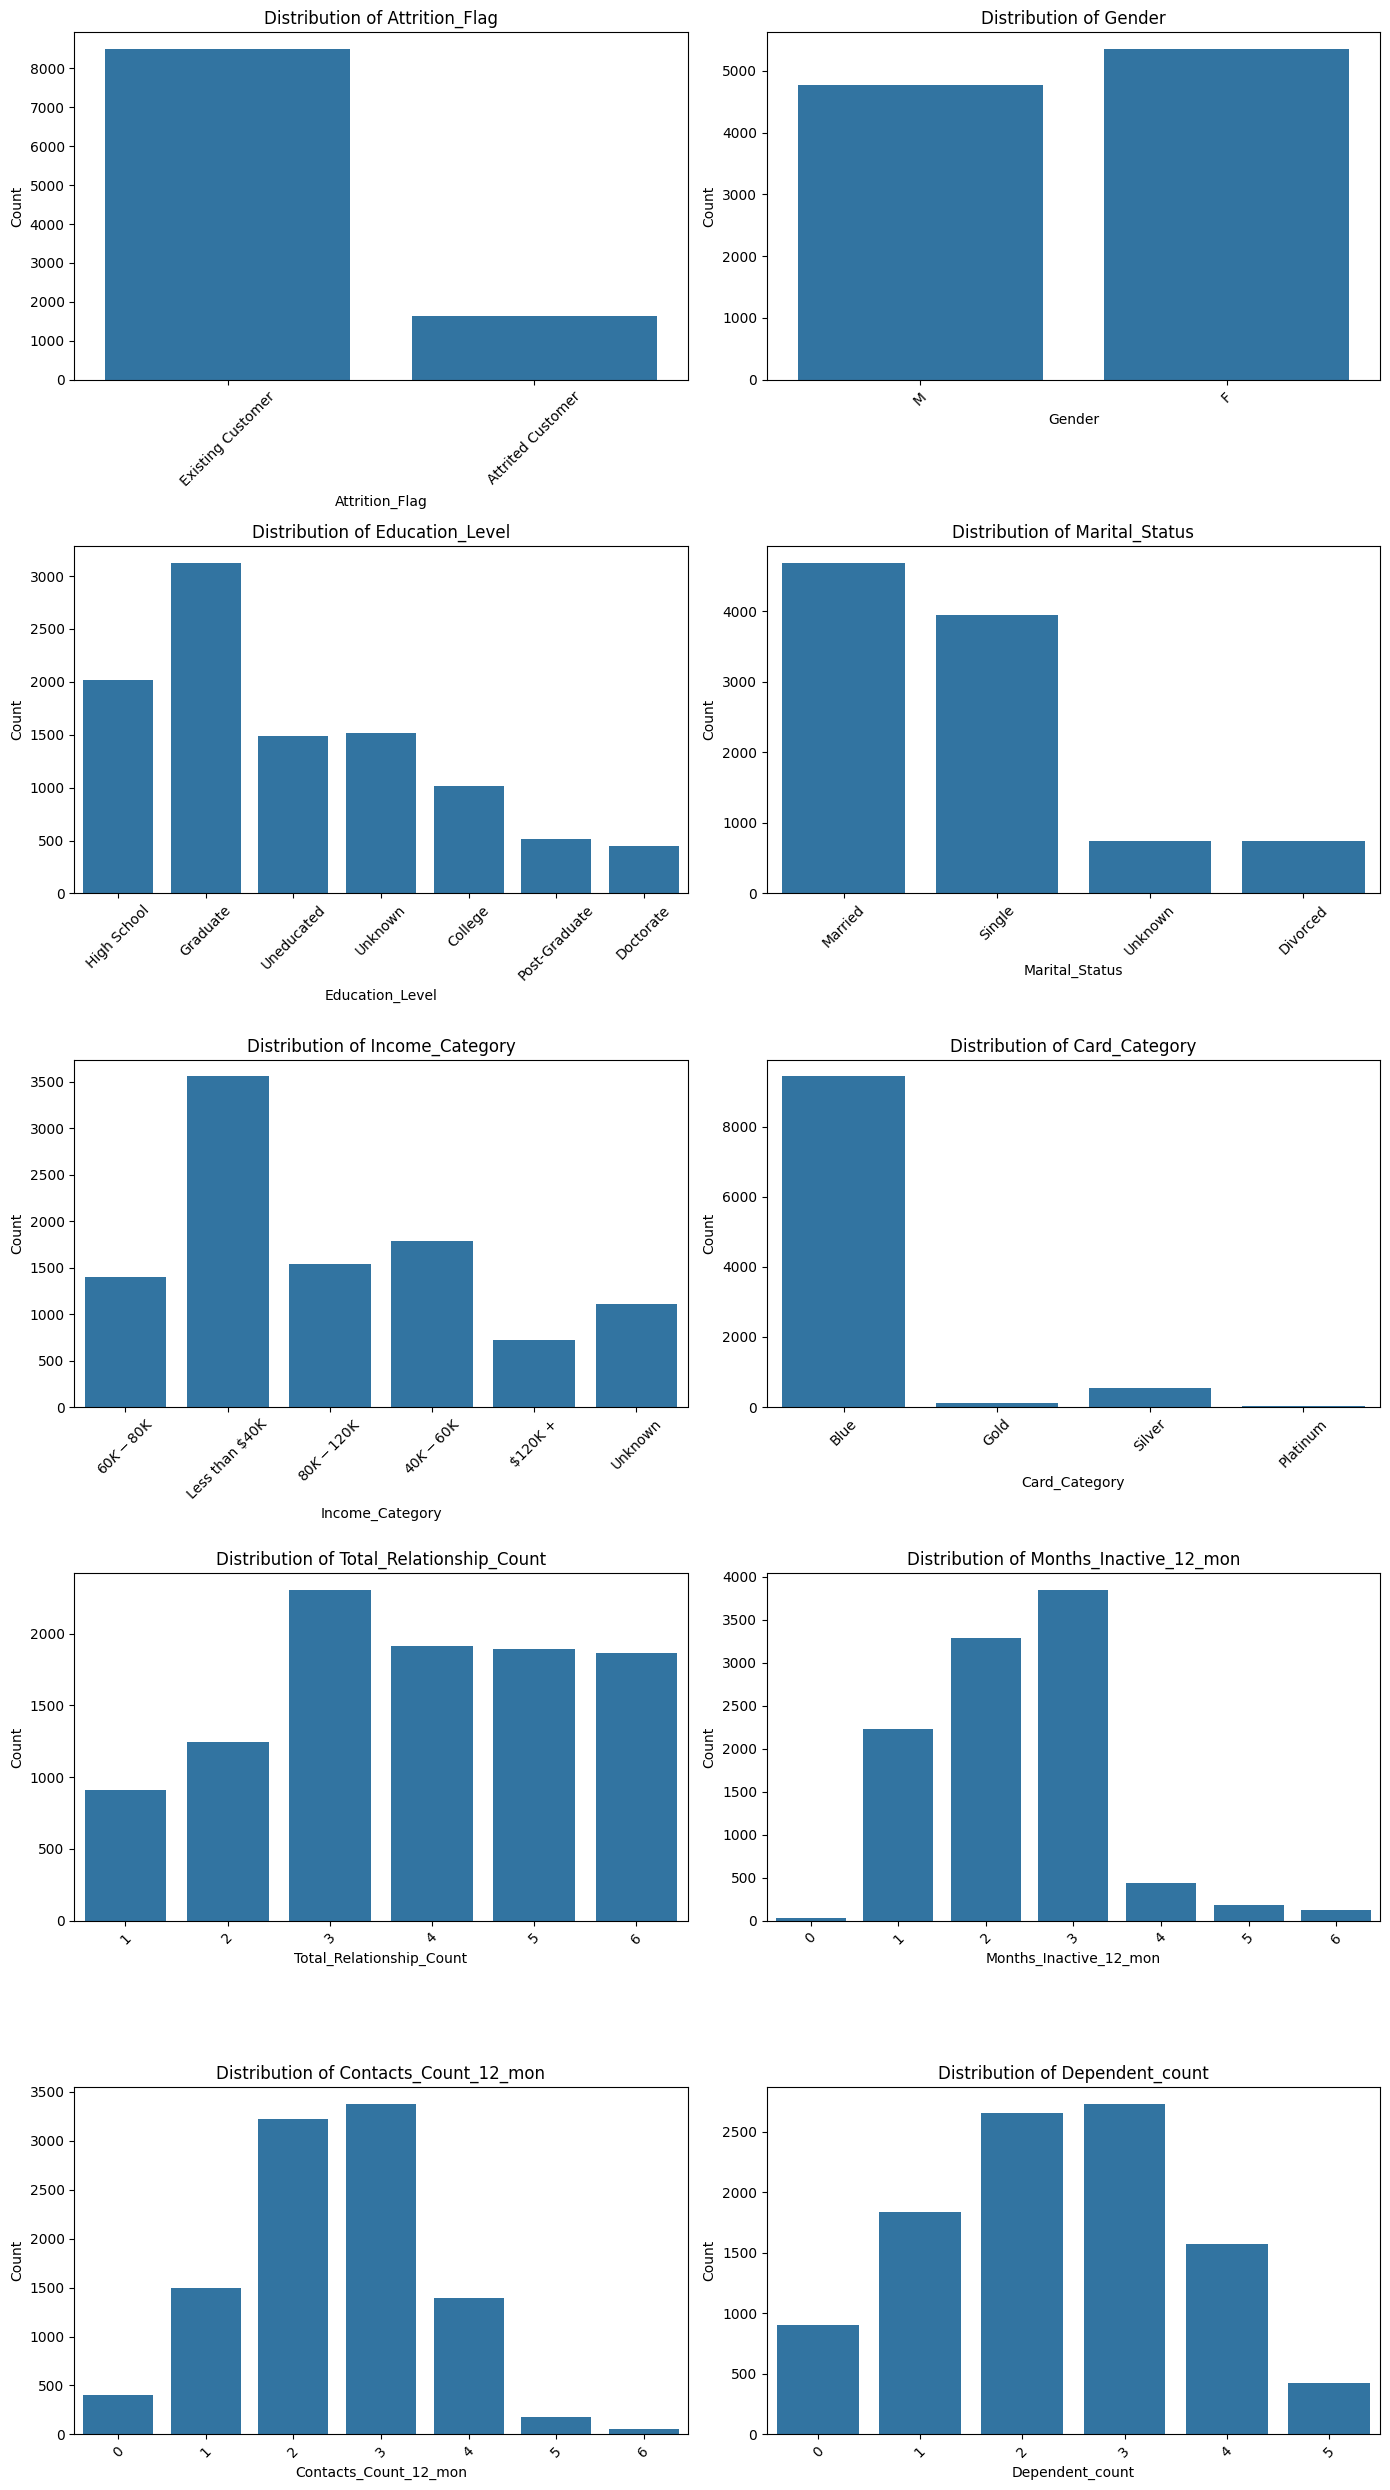

In [9]:
import math
num_cols_per_row = 2
num_rows = math.ceil(len(cat_columns) / num_cols_per_row)
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(7 * num_cols_per_row, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(cat_columns):
    sns.countplot(x=col, data=data, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

#### **Distribution of Attrition Flag Pie Chart**

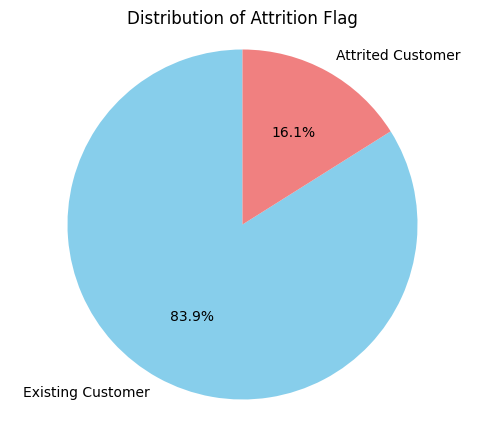

In [10]:
churn_counts = data['Attrition_Flag'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Attrition Flag')
plt.axis('equal')
plt.show()

In [11]:
print('Attrition Flag Counts and Percentages:')
print(data['Attrition_Flag'].value_counts())
print('\nAttrition Flag Percentages:')
print((data['Attrition_Flag'].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

Attrition Flag Counts and Percentages:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Attrition Flag Percentages:
Attrition_Flag
Existing Customer    83.93%
Attrited Customer    16.07%
Name: proportion, dtype: object


#### **Numerical Columns**


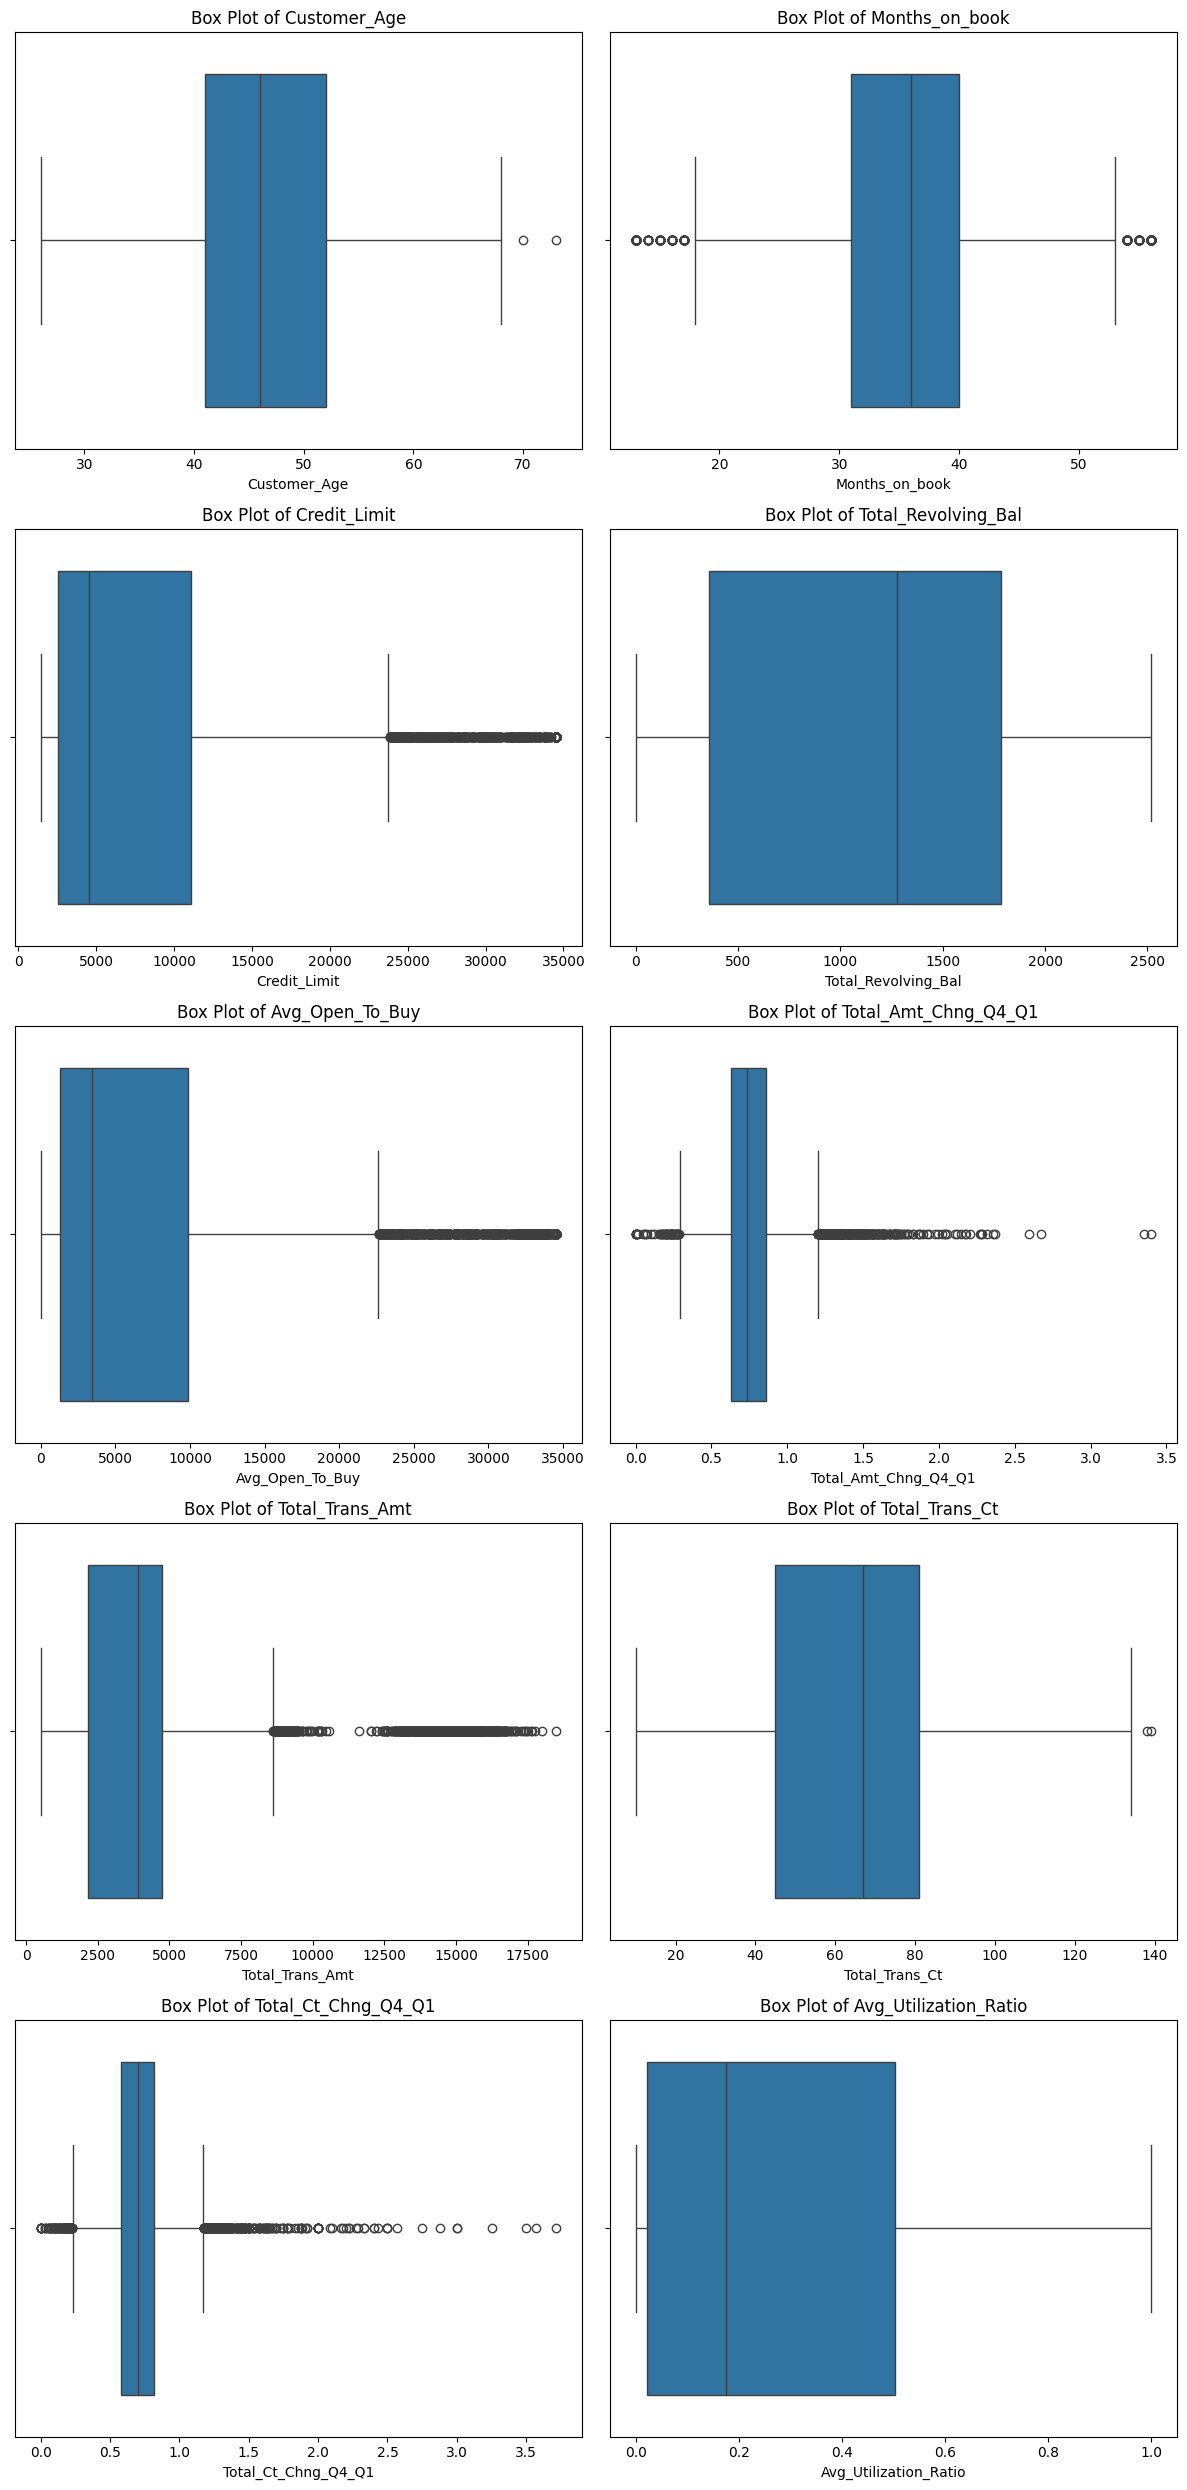

In [12]:

num_cols_per_row = 2
num_rows = math.ceil(len(num_columns) / num_cols_per_row)
fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(6 * num_cols_per_row, 5 * num_rows))
axes = axes.flatten()

for i, column in enumerate(num_columns):
    sns.boxplot(x=data[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column}')
    axes[i].set_xlabel(column)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **Bivariate Analysis**

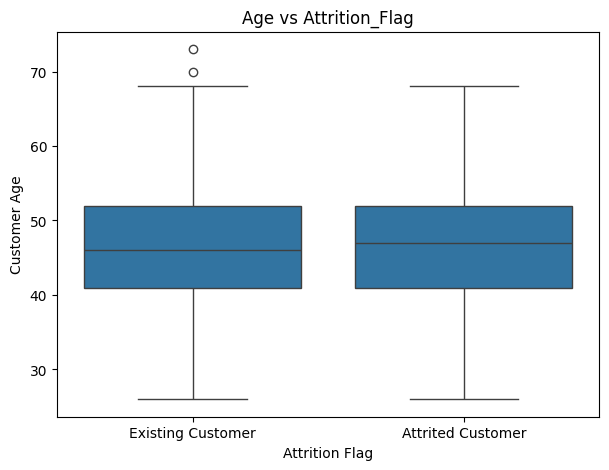

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=data)
plt.title('Age vs Attrition_Flag')
plt.xlabel('Attrition Flag')
plt.ylabel('Customer Age')
plt.show()


  
1. **Age distribution is similar for both categories**, with **median ages** close to each other, indicating that customer attrition is not significantly affected by age.  
2. **Existing Customers have a few outliers in the older age range (above 70 years old)**, but overall, both groups exhibit a comparable spread in ages.  


**Age Distribution by Attrition Flag (Violin Plot)**

A violin plot combines a box plot with a kernel density estimate, showing the distribution of numerical data across different categories. Let's revisit Customer Age against Attrition Flag with a violin plot for a more detailed view of age distribution for each churn group.

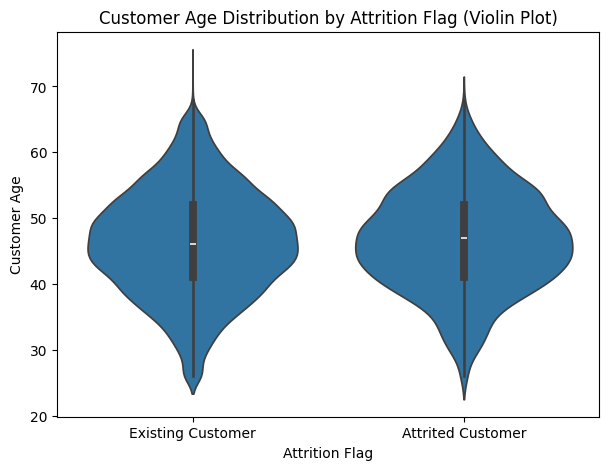

In [14]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='Attrition_Flag', y='Customer_Age', data=data)
plt.title('Customer Age Distribution by Attrition Flag (Violin Plot)')
plt.xlabel('Attrition Flag')
plt.ylabel('Customer Age')
plt.show()

**Distribution of Income Category**

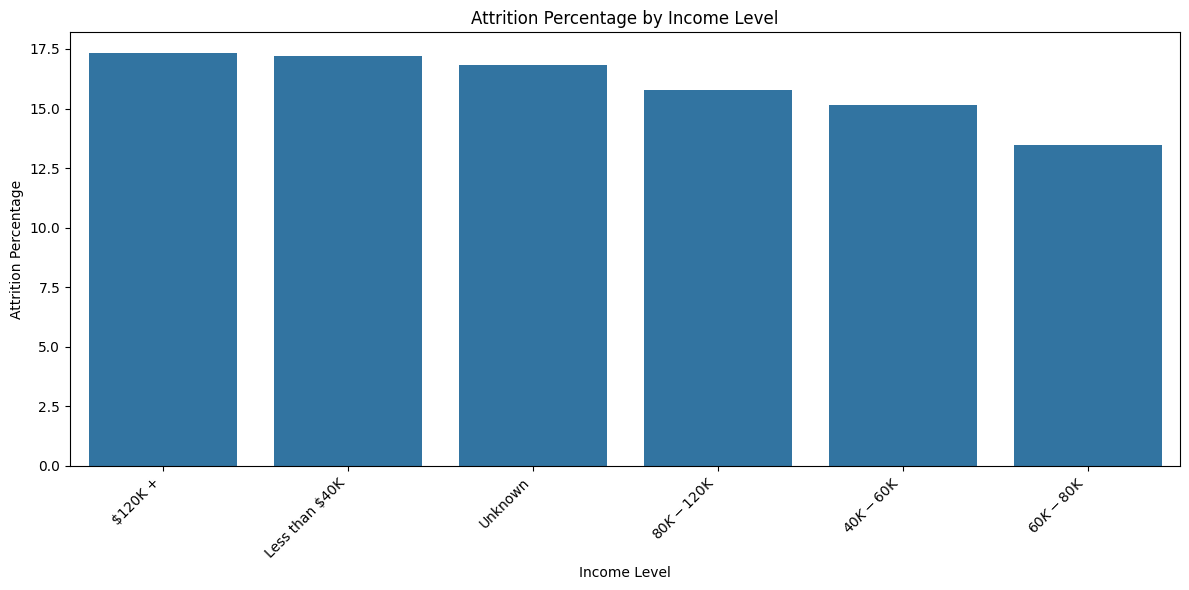

In [15]:

income_churn_counts = data.groupby(['Income_Category', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
income_churn_percentage = (income_churn_counts['Attrited Customer'] / (income_churn_counts['Attrited Customer'] + income_churn_counts['Existing Customer'])) * 100

churn_percentage_df = pd.DataFrame({'Percentage': income_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


- **$120K+** income customers have the highest attrition percentage (17.4%), indicating a higher likelihood of churn in this group.

- **Less than $40K** income customers have the second-highest attrition percentage (17.2%), suggesting that lower income customers are at a higher churn risk.

- The **Unknown** income category shows a slightly lower attrition percentage (16.8%).

- Income categories **80K - 120K** (15.8%), **40K - 60K** (15.1%), and **60K - 80K** (13.5%) show progressively lower attrition percentages, with the highest retention observed in the **60K - 80K** category.

**Distribution of Transaction Amount vs. Customer Churn**

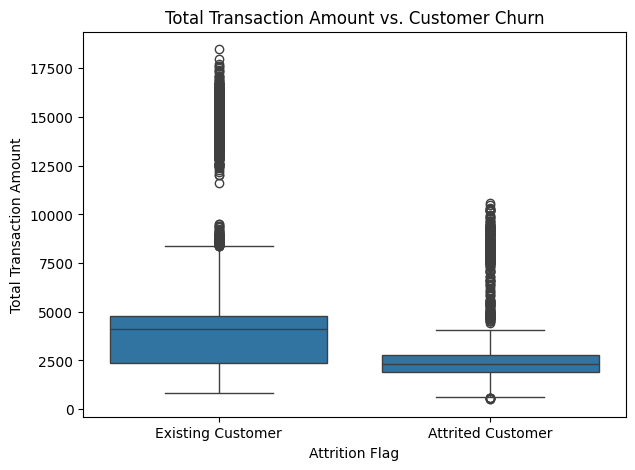

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=data)
plt.title('Total Transaction Amount vs. Customer Churn')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Amount')
plt.show()


- The box plot reveals that customers who spend less are more likely to churn.
-The analysis shows that customers who spend approximately more than $11,000 are less likely to churn.

**Credit Limit Distribution by Attrition Flag**

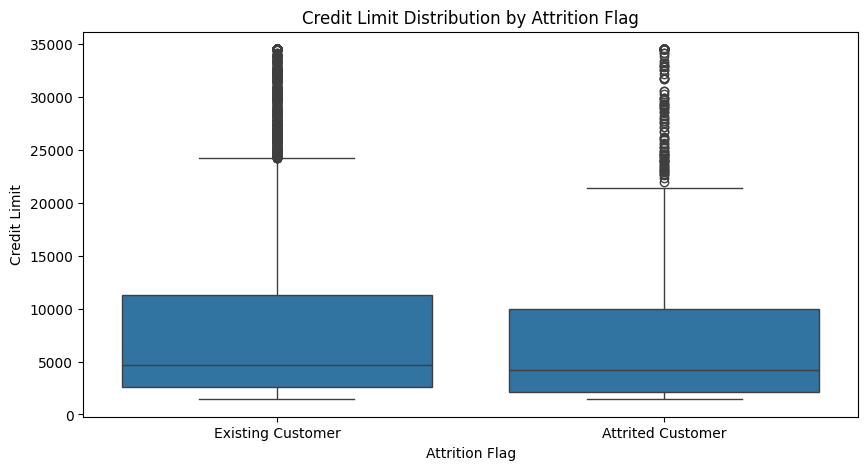

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=data)
plt.title('Credit Limit Distribution by Attrition Flag')
plt.xlabel('Attrition Flag')
plt.ylabel('Credit Limit')
plt.show()


- The overall distribution of credit limits is similar between Existing and Attrited Customers.

- Customers with very high credit limits are more commonly found in the Existing Customer category.



**Distribution of Credit Card Category**

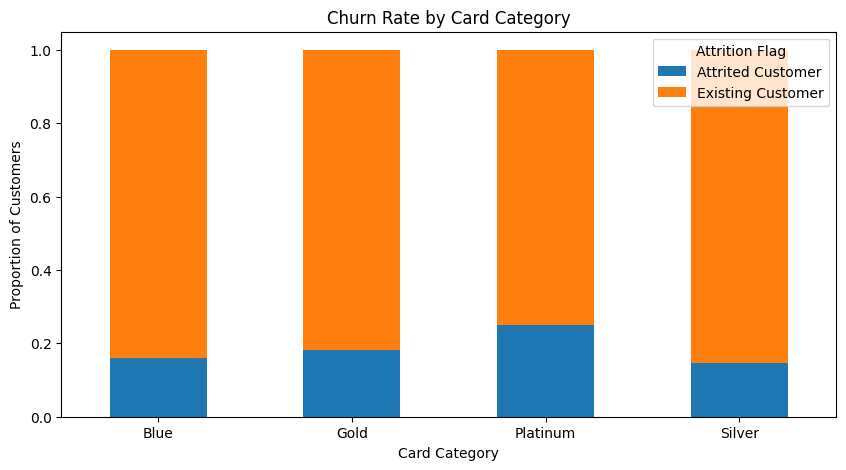

In [18]:
# Calculate the churn rate for each card category
churn_rates = data.groupby('Card_Category')['Attrition_Flag'].value_counts(normalize=True).unstack()

# Create the stacked bar chart
churn_rates.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Churn Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.legend(title='Attrition Flag')
plt.show()



1. **Platinum cardholders have the highest churn rate**, as the proportion of **Attrited Customers** is higher compared to other categories.  
2. **Silver and Blue cardholders have the lowest churn rate**, indicating that customers in this category are more likely to remain **Existing Customers**.  

**Distribution of Inactive Customer**

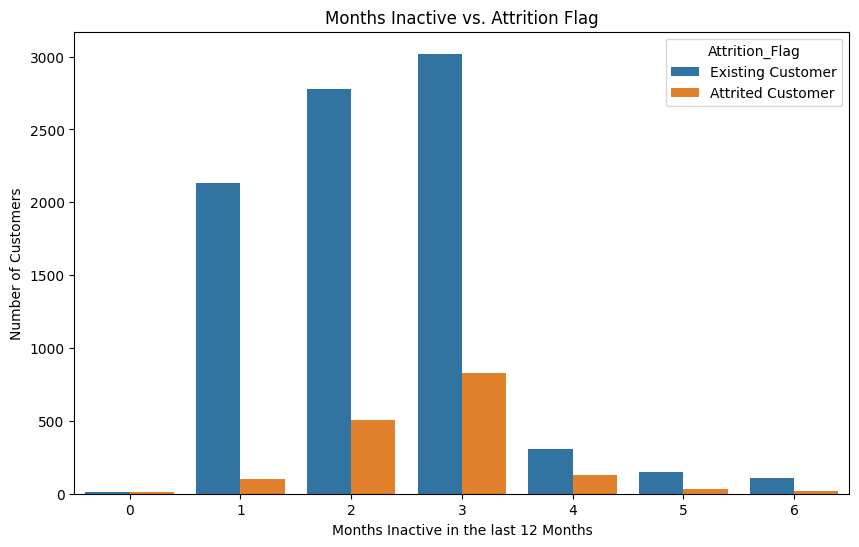

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Months_Inactive_12_mon', hue='Attrition_Flag', data=data)
plt.title('Months Inactive vs. Attrition Flag')
plt.xlabel('Months Inactive in the last 12 Months')
plt.ylabel('Number of Customers')
plt.show()


Customers inactive for 1-3 months dominate, with the highest attrition at 3 months. Attrition risk rises with inactivity, peaking at 3 months before sharply dropping. Engaging customers early (1-3 months inactive) can help reduce churn.

## **Data Preprocessing**

In this step, we will do two important things:

**1. Encoding Categorical Variables**
Some of the columns in our dataset contain text values, like gender, income category, or card type. Since machine learning models work best with numbers, we need to convert these text values into numerical values using encoding methods.

**2. Splitting the Data**
To check how well our model works, we need to split the dataset into two parts:
- **Training set** – This part is used to train the model.
- **Testing set** – This part is used to test how well the model performs on new data.

Let’s begin preparing the data for modeling.

We are dropping the **CLIENTNUM** column as it is a unique identifier and doesn't contribute to model building.


In [20]:
data = data.drop('CLIENTNUM', axis=1)


In [22]:

attrition_mapping = {'Existing Customer': 0, 'Attrited Customer': 1}

data['Attrition_Flag'] = data['Attrition_Flag'].map(attrition_mapping)
education_mapping = {
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6,
    'Unknown':0
}

data['Education_Level'] = data['Education_Level'].map(education_mapping)

income_mapping = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0
}

data['Income_Category'] = data['Income_Category'].map(income_mapping)


We use **n-1 dummy encoding** when the unique values in a categorical column are less than 10 to avoid multicollinearity, by dropping one category as the reference and preventing redundancy in the model.

In [23]:

data = pd.get_dummies(data, columns=['Marital_Status', 'Card_Category'],
                            drop_first=True, dtype=int)


In [24]:

le = LabelEncoder()

data['Gender'] = le.fit_transform(data['Gender'])


### **Train Test Split**

***Prompt***:

<font size=3 color="navyblue">Split the data into training and testing sets, using `Attrition_Flag` as the Dependent variable (`y`). Use 70% of the data for training and 30% for testing, while maintaining the same proportion of `Attrition_Flag` in both sets.


</font>

In [25]:

y = data['Attrition_Flag']
X = data.drop('Attrition_Flag', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7088, 23)
X_test shape: (3039, 23)
y_train shape: (7088,)
y_test shape: (3039,)


## **Model Building**

### **Model Evaluation Criterion**

In customer churn prediction, missing actual churners (false negatives) is costly as it leads to lost customers.
To reduce this risk, the model should:

* **Maximize Recall** to catch more true churn cases
* **Minimize False Negatives** to avoid missing at-risk customers

This helps improve retention and reduce revenue loss.


In [26]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                                           'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1'])


### **Decision Tree Classifier**

A Decision Tree is a supervised learning algorithm used for both classification and regression tasks. It splits the data into branches based on feature values, forming a tree-like structure of decisions. It is easy to interpret, visualize, and doesn't require feature scaling. However, it can easily overfit the training data if not pruned (trimmed to reduce complexity by removing unnecessary branches).

**Key Points**

* Works well for small to medium-sized datasets with clear decision boundaries.
* Handles both numerical and categorical features.
* Prone to overfitting, so pruning or ensemble methods like Random Forest are often used.


In [27]:
# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on training and testing data
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Evaluate the model on training data
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
train_precision_dt = precision_score(y_train, y_train_pred_dt)
train_recall_dt = recall_score(y_train, y_train_pred_dt)
train_f1_dt = f1_score(y_train, y_train_pred_dt)

# Evaluate the model on testing data
test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
test_precision_dt = precision_score(y_test, y_test_pred_dt)
test_recall_dt = recall_score(y_test, y_test_pred_dt)
test_f1_dt = f1_score(y_test, y_test_pred_dt)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Decision Tree', train_accuracy_dt, train_precision_dt, train_recall_dt, train_f1_dt,
                                                  test_accuracy_dt, test_precision_dt, test_recall_dt, test_f1_dt]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results


Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80


* **Train Performance**: Perfect scores (1.00) across all metrics suggest that the model has memorized the training data.
* **Test Performance**: Accuracy is decent at 0.93, but **precision (0.78)** and **recall (0.81)** drop significantly.
* **Inference**: The model is **overfitting** — it performs very well on training data but generalizes poorly to unseen data.




**Note**: We use `random_state=42` to control the randomness in processes like data shuffling and splitting, ensuring reproducibility and consistency of results across different runs, and you can choose any integer value for `random_state` as long as it remains consistent.

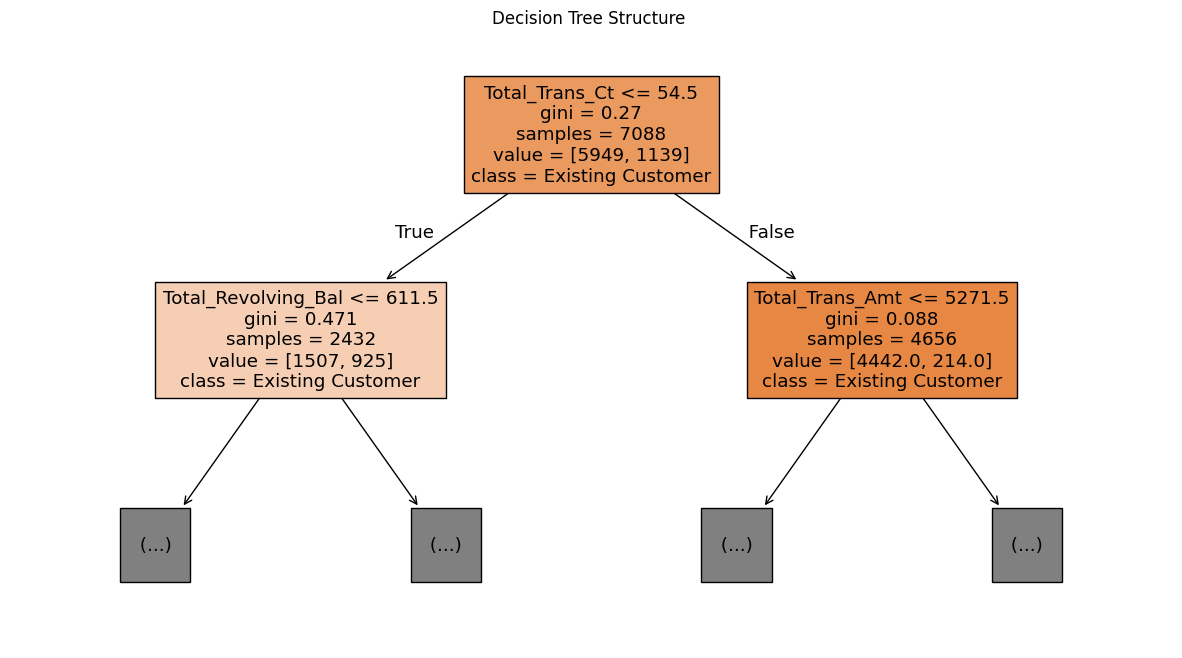

In [28]:
from sklearn.tree import plot_tree, export_text

# Visualize the decision tree with max_depth=1 for the easiest visual interpretation
plt.figure(figsize=(15, 8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=1)
plt.title("Decision Tree Structure ")
plt.show()


### **Random Forest**

Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to improve accuracy and reduce overfitting. It uses bagging (a combination of random sampling with replacement and aggregation) and random feature selection, making it more robust and generalizable than a single decision tree. It performs well on both classification and regression tasks.


**Key Points**

* Reduces overfitting by averaging the results of many trees.
* Handles missing values and works well with large datasets.
* Less interpretable than a single decision tree but more accurate.


In [29]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on testing data
y_test_pred_rf = rf_model.predict(X_test)

# Make predictions on training data
y_train_pred_rf = rf_model.predict(X_train)

# Evaluate the model on training data
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_precision_rf = precision_score(y_train, y_train_pred_rf)
train_recall_rf = recall_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf)

# Evaluate the model on testing data
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf)
test_recall_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Random Forest', train_accuracy_rf, train_precision_rf, train_recall_rf, train_f1_rf,
                                                  test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results


Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80
1,Random Forest,1.00,1.00,1.00,1.00,0.96,0.92,0.80,0.85


* **Train Performance**: Also shows perfect scores (1.00), indicating a strong fit to training data.
* **Test Performance**: High accuracy (0.96) and better balance across metrics — precision (0.92), recall (0.80), and F1 (0.85).
* **Inference**: Although slightly overfitting, the model still generalizes **well to test data**, making it more reliable than the Decision Tree.



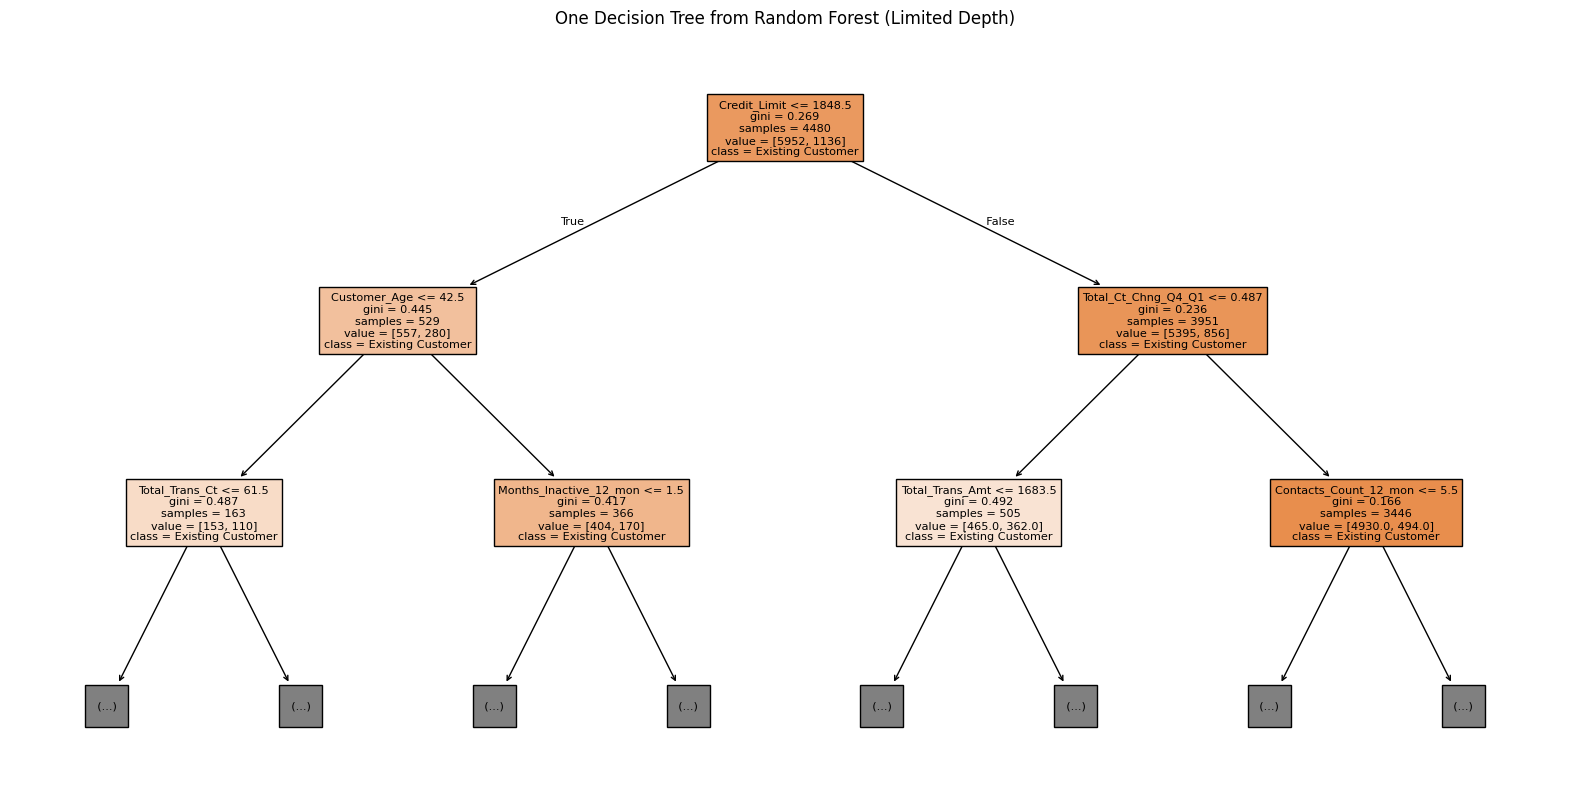

In [30]:
# You can visualize one of the trees from the Random Forest
plt.figure(figsize=(20,10))
# Select the first tree from the forest
plot_tree(rf_model.estimators_[0], filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("One Decision Tree from Random Forest (Limited Depth)")
plt.show()

### **Gradient Boosting**

Gradient Boosting is an ensemble technique that builds models sequentially, where each new model corrects the errors of the previous ones. It combines weak learners (usually decision trees) into a strong predictor by minimizing a loss function. It’s highly accurate but can be sensitive to overfitting if not tuned properly.

**Key Points**

* Delivers strong predictive performance on both classification and regression tasks.
* Requires careful tuning of parameters like learning rate and tree depth.
* More computationally intensive than Random Forest but often more accurate.


In [31]:
# Initialize Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions on testing data
y_test_pred_gb = gb_model.predict(X_test)

# Make predictions on training data
y_train_pred_gb = gb_model.predict(X_train)

# Evaluate the model on training data
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_precision_gb = precision_score(y_train, y_train_pred_gb)
train_recall_gb = recall_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb)

# Evaluate the model on testing data
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_precision_gb = precision_score(y_test, y_test_pred_gb)
test_recall_gb = recall_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Gradient Boosting', train_accuracy_gb, train_precision_gb, train_recall_gb, train_f1_gb,
                                                  test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results



Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80
1,Random Forest,1.00,1.00,1.00,1.00,0.96,0.92,0.80,0.85
2,Gradient Boosting,0.98,0.96,0.90,0.93,0.96,0.93,0.81,0.86


* **Train Performance**: Slightly below perfect, with accuracy (0.98), precision (0.96), recall (0.90), and F1 (0.93), indicating good learning without severe overfitting.
* **Test Performance**: Strong generalization with **accuracy (0.96)**, precision (0.93), recall (0.81), and F1 (0.86).
* **Inference**: Offers the **best balance between bias and variance** — great performance on both training and test sets with minimal overfitting.


## **Final Model Selection**

### **Model Comparison**

Among the three models, Gradient Boosting provides the best balance between training and test performance, with high precision, recall, and F1-score on unseen data. While Decision Tree and Random Forest show signs of overfitting, Gradient Boosting generalizes better than them.
**Therefore, Gradient Boosting is selected as the final model.**


### **Feature Importance**

Top 10 Features Impacting Customer Churn:
                     Feature  Importance
14            Total_Trans_Ct        0.33
13           Total_Trans_Amt        0.19
10       Total_Revolving_Bal        0.19
6   Total_Relationship_Count        0.11
15       Total_Ct_Chng_Q4_Q1        0.10
12      Total_Amt_Chng_Q4_Q1        0.03
8      Contacts_Count_12_mon        0.02
0               Customer_Age        0.02
7     Months_Inactive_12_mon        0.01
11           Avg_Open_To_Buy        0.00


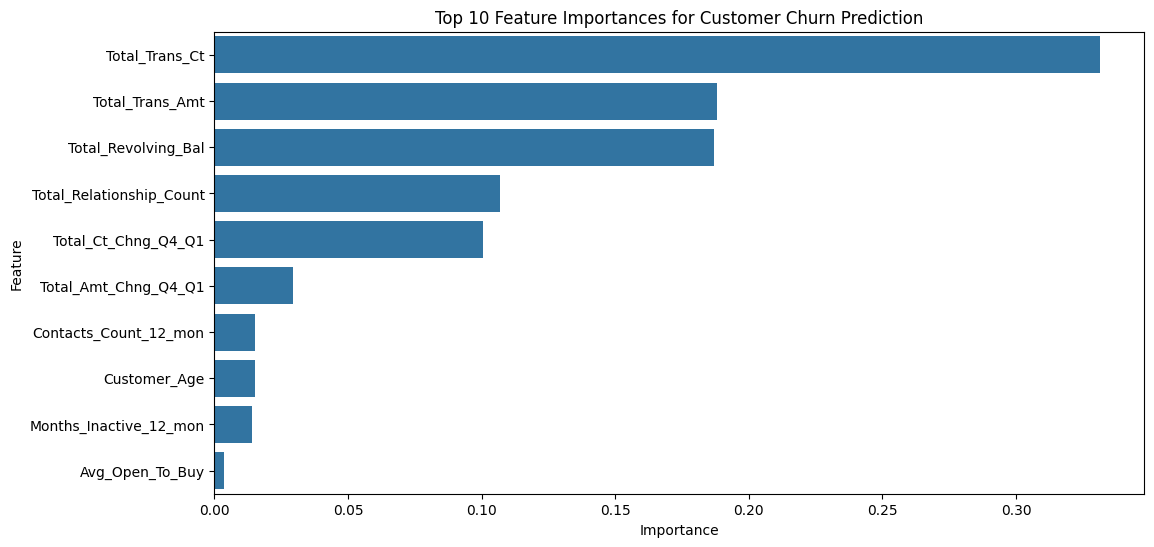

In [32]:
# Get feature importances from the trained Gradient Boosting model
feature_importances = gb_model.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Print the top 10 features that most significantly impact customer churn
print("Top 10 Features Impacting Customer Churn:")
print(feature_importance_df.head(10))

# You can visualize the feature importances using a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances for Customer Churn Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The top three attributes influencing customer churn are **Total\_Transaction\_Count**, **Total\_Transaction\_Amount**, and **Total\_Revolving\_Balance**.

### **Gradient Boosting - Fine Tuning**

 - The process of fine-tuning the Gradient Boosting model. It involves defining a hyperparameter grid with various values for n_estimators, learning_rate, max_depth, and subsample.

 - Then, a GradientBoostingClassifier is initialized, and GridSearchCV is used to systematically search for the best combination of these hyperparameters, optimizing for 'recall'. Finally, the model is trained with these best parameters, and its performance is evaluated to ensure it effectively predicts customer churn.

In [33]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [75, 100 , 125],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.5, 0.6]
}

# Initialize the Gradient Boosting Classifier
gb_model_tuned = GradientBoostingClassifier(random_state=42)

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=gb_model_tuned, param_grid=param_grid, scoring='recall', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Train the best model found by GridSearchCV
best_gb_model = grid_search.best_estimator_
best_gb_model.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=4, n_estimators=125, random_state=42,
                           subsample=0.5)

**The parameters for the Tuned Gradient Boosting model are:**

* `max_depth = 4`: Restricts the depth of each tree, helping to balance model complexity and overfitting.
* `n_estimators = 125`: Uses 125 boosting rounds (trees) to build a strong ensemble without excessive computation.
* `subsample = 0.5`: Trains each tree on a random 50% subset of the data, introducing regularization and helping to reduce overfitting.
* `random_state = 42`: Ensures reproducibility of results.



In [34]:
# Make predictions on training and testing data with the fine-tuned model
y_train_pred_tuned = best_gb_model.predict(X_train)
y_test_pred_tuned = best_gb_model.predict(X_test)

# Evaluate the fine-tuned model on training data
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)
train_precision_tuned = precision_score(y_train, y_train_pred_tuned)
train_recall_tuned = recall_score(y_train, y_train_pred_tuned)
train_f1_tuned = f1_score(y_train, y_train_pred_tuned)

# Evaluate the fine-tuned model on testing data
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_precision_tuned = precision_score(y_test, y_test_pred_tuned)
test_recall_tuned = recall_score(y_test, y_test_pred_tuned)
test_f1_tuned = f1_score(y_test, y_test_pred_tuned)

# Store the results in model_eval_results
model_eval_results.loc[len(model_eval_results)] = ['Gradient Boosting (Tuned)', train_accuracy_tuned, train_precision_tuned, train_recall_tuned, train_f1_tuned,
                                                  test_accuracy_tuned, test_precision_tuned, test_recall_tuned, test_f1_tuned]

# Show the model evaluation results dataframe
print("\nModel Evaluation Results:")
model_eval_results



Model Evaluation Results:


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,Decision Tree,1.00,1.00,1.00,1.00,0.93,0.78,0.81,0.80
1,Random Forest,1.00,1.00,1.00,1.00,0.96,0.92,0.80,0.85
2,Gradient Boosting,0.98,0.96,0.90,0.93,0.96,0.93,0.81,0.86
3,Gradient Boosting (Tuned),0.99,0.98,0.96,0.97,0.96,0.93,0.84,0.88


After fine-tuning the Gradient Boosting model, we observed an improvement in performance metrics, particularly an **increase in recall on the test set** compared to the base model. This means the tuned model is now better at correctly identifying customers who are likely to churn.


## **New Prediction on unseen Observation**

Now, let's create a new customer observation and use our `best_gb_model` (the fine-tuned Gradient Boosting model) to predict whether this customer is likely to churn.

In [35]:
new_observation = pd.DataFrame({
    'Customer_Age': [45],
    'Gender': [1],
    'Dependent_count': [2],
    'Education_Level': [3],
    'Income_Category': [2],
    'Months_on_book': [36],
    'Total_Relationship_Count': [3],
    'Months_Inactive_12_mon': [2],
    'Contacts_Count_12_mon': [2],
    'Credit_Limit': [5000.00],
    'Total_Revolving_Bal': [500],
    'Avg_Open_To_Buy': [4500.00],
    'Total_Amt_Chng_Q4_Q1': [0.6],
    'Total_Trans_Amt': [1500],
    'Total_Trans_Ct': [30],
    'Total_Ct_Chng_Q4_Q1': [0.5],
    'Avg_Utilization_Ratio': [0.1],
    'Marital_Status_Married': [1],
    'Marital_Status_Single': [0],
    'Marital_Status_Unknown': [0],
    'Card_Category_Gold': [0],
    'Card_Category_Platinum': [0],
    'Card_Category_Silver': [0]
})

new_observation = new_observation[X_train.columns]

predicted_churn = best_gb_model.predict(new_observation)

if predicted_churn[0] == 1:
    print("Predicted Churn: Attrited Customer (Likely to churn)")
else:
    print("Predicted Churn: Existing Customer (Unlikely to churn)")

predicted_churn_proba = best_gb_model.predict_proba(new_observation)

new_observation_probabilities = pd.DataFrame(predicted_churn_proba, columns=['Existing Customer', 'Attrited Customer'])
new_observation_probabilities

Predicted Churn: Existing Customer (Unlikely to churn)


,Existing Customer,Attrited Customer
0,0.84,0.16


Although some features like `Total_Revolving_Bal`, `Total_Trans_Amt`, and `Total_Trans_Ct` are low (which can be indicators of churn), the combination of these features with other factors, like having an average `Total_Relationship_Count` and moderate `Credit_Limit`, leads the model to classify this customer as 'Existing'.

# Conclusion



#### **Unseen Data Prediction**

*   **Model Classification:** Our fine-tuned Gradient Boosting model classified the new, unseen customer as an 'Existing Customer'.
*   **Probability:** The prediction came with an 83.9% probability of being an 'Existing Customer' (0.84 for existing, 0.16 for attrited).
*   **Generalization:** This demonstrates the model's ability to generalize to new data. Even with some churn-indicative features, the overall profile of this specific customer did not strongly align with the 'Attrited Customer' class as perceived by the model.

#### **Overall Best Model**

*   **Evaluated Models:** We evaluated Decision Tree, Random Forest, and Gradient Boosting models.

*   **Fine-Tuning Impact:** Further fine-tuning of the Gradient Boosting model led to improved recall, enhancing its effectiveness in identifying potential churners.

*   **Final Choice:** The **fine-tuned Gradient Boosting model (`best_gb_model`)** was selected as the optimal model for this customer churn prediction project due to its superior generalization capabilities and improved ability to identify at-risk customers.